### adjustment of confounding 이란?
"confounder를 조건화(conditioning)하여 treatment–outcome 간의 가짜 상관(spurious correlation)을 제거하는 과정"
Kim, C., Tec, M., and Zigler, C. Bayesian nonparametric adjustment of confounding. Biometrics (2023).

탐색 시작 : https://playinpap.github.io/adjustment-for-confounding/

- Y : outcome (결과)
- T : treatment (처리)
- X : covariates (처리 T와 독립이고, Y에만 영향을 주는 변수)
- Z : confounder (처리 T와 결과 Y 모두 영향을 주는 변수)

#### 교란변수란?
- 처리(T)에도 영향을 주고, 결과(Y)에도 영향을 주는 변수
- 이 변수가 존재하는 경우 추론 결과에 문제가 발생할 수 있음.

#### 교란변수가 작용하는 예시
- 아이스크림 판매량(X)이 늘면 익사 사고(Y)가 늘어난다? (온도가 교란변수로 존재해서, 이를 통제해야 신뢰할 수 있음)
- 유기농 식품을 많이 먹는 사람(X)이 건강하다(Y) (건강에 대한 높은 관심도(교란 변수)를 통제해야 함)


#### 보통 어떻게 우리는 제어하고 있나?
- RCT
- 성향 점수 기반 샘플링 (RCT 불가능 시 - 대응 표본 전략)
- 층화 표본 추출 (특정 집단별로 실험 설계)


### BART 기반 모델링 -> 우리 교란변수랑 공변량이 섞여있는 잠재 변수들만 가지고 효과를 예측해 보자

관련 패키지
- https://cran.r-project.org/web/packages/bartcs/index.html
- https://www.rdocumentation.org/packages/bartCause/versions/1.0-10/topics/bartc

실행시 R이나 관련 패키지는 알아서 설치해 올것.

Fit Bayesian Regression Additive Trees (BART) models to select true confounders from a large set of potential confounders and to estimate average treatment effect. For more information, see Kim et al. (2023)


데이터의 표현 방식
- X1, X2, X3 ... Xp   (많은 공변량인지 교란변순인지, 그냥 잡음일지 알 수 없는 변수들)
- A                   (treatment)
- Y                   (outcome)

우리가 진짜 알고 싶은 값 (DID를 통해 확인할 것.)
- ATE = E[Y(1) − Y(0)]
- 우리가 측정 가능한 값 : E[Y | A=1] − E[Y | A=0]

상세 설명
- ITE(개인 처리 효과) = Y_1i − Y_0i  (알수 없는 값)
    - 당연히 어떤 한사람(i번째 사람)이 처리(T = 0 or 1)를 받았다면, 처리를 안받았을 때 결과를 측정할 수 없다.
- ATE(평균 처리 효과) = E[Y(1) − Y(0)]
​- ATT(평균 처치 효과) = E[Y_1 − Y_0 ∣ T=1]


- 통제군 (처리를 받은 집단과 아닌 집단)의 차이가 없을 때, Association = ATT가 성립한다
    - Association = E[Y ∣ T=1] − E[Y ∣ T=0]
    - = E[Y1 ∣ T=1] − E[Y0 ∣ T=0]
    - = E[Y1 ∣ T=1] − E[Y0 ∣ T=0] + E[Y0 ∣ T=1] − E[Y0 ∣ T=1]
    - = {E[Y1 ∣ T=1] − E[Y0 ∣ T=0]} + {E[Y0 ∣ T=1] − E[Y0 ∣ T=1]} = ATT(평균 처치 효과) + BIAS(편향)
- 다시 말해 편향이 통제되는 경우 두 집단의 평균 차이가 곧 인과 효과(causal effect) 될 수 있다
    - 이 편향을 없애기 위한 방법으로는, 두 집단에 차이를 만들어 내는 cofounder를 제거해야함 함  


bartc 모델이 동작하는 방식

1. E[A | X] (treatment assignment model)를 추정한다
2. E[Y | A, X] (outcome model)을 추정한다
3. 두 모델은 독립적으로 훈련되지 않고, exposure model과 outcome model이 shared Dirichlet prior를 공유하여 훈련된다
    a. BART에서 변수 선택은 split probability로 표현됨.
    b. s_i = 변수 X_i가 tree Model에서 분할 되는 확률
    c. BART 모델의 기초는 s = (s1, s2 ... sp)가 Dirichlet prior를 따르고, s ~ Dirichlet(α/p ... α/p)에 따라 변수 선택을 수행함
    d. "두 모델에서 동일한 변수 선택 확률"을 가짐 -> treatment assignment model과, outcome model 모두 중요한 변수다?라는 명제는 공변량의 조건을 충족함 (처리와 결과 모두에 강한 영향을 주니까)
    e. 즉, P(confounder | data)의 확률값을 posterior inclusion probability로 정의한다
4. 모델에서 확보한 shared Dirichlet prior를 통한 MCMC 샘플링, 사후 확률 연산
5. 각 변수에 대한 posterior inclusion probability 연산
6. 이 사후확률로 확보된 변수를 통해 ATE 추정

주의사항
- 도메인 지식은 무엇보다 중요하다. 확실하게 식별이 되지 않을때 대안으로만 사용해야함.
causal structure는 완전히 식별되지 않는다

예제 코드 출처
- https://cran.r-project.org/web/packages/bartcs/refman/bartcs.html

In [2]:
%load_ext rpy2.ipython

/Users/naeae/Documents/GitHub/DataAnalyticsTools/.venv/lib/python3.14/site-packages/rpy2/rinterface_lib/embedded.py:333: UserWarning: R was initialized outside of rpy2 (R_NilValue != NULL). Trying to use it nevertheless.
  warnings.warn(msg)
R was initialized outside of rpy2 (R_NilValue != NULL). Trying to use it nevertheless.
/Users/naeae/Documents/GitHub/DataAnalyticsTools/.venv/lib/python3.14/site-packages/rpy2/ipython/rmagic.py:96: UserWarning: The Python package `pandas` is strongly recommended when using `rpy2.ipython`. Unfortunately it could not be loaded, as we did not manage to load `numpy` in the first place (error: No module named 'numpy').
  warnings.warn('The Python package `pandas` is strongly '


### 기본 사용 형태

모델링 함수
- single_bart - 하나의 outcome model을 가진다 (총 모델 2개, 전체 데이터 사용, 적은 샘플에도 안정적, heterogeneity에 딱히 약하지는 않음)
- separate_bart - Y(1), Y(0) 각각 모델 (총 모델 3개, 데이터 분할(처리에 따라), 적은 샘플 불안정함, heterogeneity에 강함)

In [24]:
%%R
library(bartcs)
data(ihdp, package = "bartcs")

fit <- single_bart(
  Y               = ihdp$y_factual,
  trt             = ihdp$treatment,
  X               = ihdp[, 6:30],
  num_tree        = 10,
  num_chain       = 4,
  num_post_sample = 100,
  num_burn_in     = 100,
  verbose         = FALSE
)

fit

`bartcs` fit by `single_bart()`

         mean     2.5%    97.5%
SATE 3.984813 3.766438 4.172903
Y1   6.410915 6.232170 6.581721
Y0   2.426102 2.348653 2.509336


mcmc_list : MCMC를 통해 추정된 리스트 
- SATE : 추정된 ATE 효과
- Y1 : 처리를 받았을때 평균 효과 추정값
- Y0 : 처리를 안받았을때 평균 효과 추정값

In [28]:
%%R
fit$mcmc_list

[[1]]
Markov Chain Monte Carlo (MCMC) output:
Start = 101 
End = 200 
Thinning interval = 1 
           SATE       Y1       Y0 dir_alpha  sigma2_out
  [1,] 4.053656 6.422699 2.369043  4.370891 0.005855927
  [2,] 3.758921 6.200564 2.441643  4.586959 0.006386609
  [3,] 3.953563 6.401532 2.447969  4.435920 0.006278449
  [4,] 4.061288 6.494554 2.433266  4.419422 0.006679760
  [5,] 3.905367 6.301636 2.396269  4.360714 0.006367239
  [6,] 4.019704 6.436265 2.416560  4.312283 0.006565617
  [7,] 3.839698 6.351599 2.511901  4.442311 0.006541791
  [8,] 4.029230 6.467065 2.437836  4.557559 0.006586581
  [9,] 4.107099 6.456621 2.349522  4.554088 0.006867735
 [10,] 3.883821 6.337476 2.453656  4.398560 0.006967764
 [11,] 3.878544 6.338356 2.459812  4.371196 0.006547591
 [12,] 4.009644 6.393296 2.383652  4.306223 0.006894770
 [13,] 4.096585 6.461950 2.365365  4.262765 0.006896300
 [14,] 3.972337 6.370771 2.398434  4.114077 0.006433443
 [15,] 3.916873 6.343866 2.426994  3.985898 0.006784953
 [16,] 4.02

var_prob : confounder probability
- var_prob가 높을수록 양쪽 모델에 선택될 확률이 높으니까 교란변수일 가능성이 높지?

In [29]:
%%R
fit$var_prob

   trt     X1     X2     X3     X4     X5     X6     X7     X8     X9    X10 
1.0000 0.0275 0.2525 0.2525 0.5300 0.1175 1.0000 0.0075 0.0250 0.2525 0.0450 
   X11    X12    X13    X14    X15    X16    X17    X18    X19    X20    X21 
0.0000 0.0050 0.2775 0.7150 1.0000 0.2850 0.1575 0.0450 0.0325 0.0200 0.0000 
   X22    X23    X24    X25 
0.0300 0.0400 0.0525 0.4000 


fit$var_count : 각 변수 split 횟수
- 이 변수를 기준으로 Tree가 N회 분기되었음.
- 설명력이 큰 변수라는 뜻 (variable importance를 그릴려면 이걸 쓰면 됨)
fit$chains : MCMC chain 결과
- fit$mcmc_list를 통해 확인하면 되는데 굳이 사용할 이유가 없음

In [36]:
%%R
fit$var_count

[[1]]
       [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12] [,13]
  [1,]    3    0    0    0    1    0    8    0    0     2     0     0     0
  [2,]    3    0    0    0    1    0    8    0    0     2     0     0     0
  [3,]    3    0    0    0    1    0    8    0    0     2     0     0     0
  [4,]    3    0    0    0    1    0    7    0    0     2     0     0     0
  [5,]    3    0    0    0    1    0    7    0    0     2     0     0     0
  [6,]    3    0    0    0    1    0    7    0    0     2     0     0     0
  [7,]    3    0    0    0    1    0    7    0    1     2     0     0     0
  [8,]    3    0    0    0    1    0    7    0    0     2     0     0     0
  [9,]    3    0    0    0    1    0    7    0    0     2     0     0     0
 [10,]    3    0    0    0    1    0    8    0    0     2     0     0     0
 [11,]    3    0    0    0    1    0    7    0    0     2     0     0     0
 [12,]    3    0    0    0    1    0    7    0    0     2     0     0     0
 [13,]

### PIP plot (Posterior Inclusion Probability)

모델 학습 중 변수들이 모델에 포함된 횟수를 계산하여 변수의 중요도를 시각화하는 방법입니다.
- 수치가 의미하는 것 : MCMC sampling 동안 그 변수가 tree split에 사용될 확률


보통 수치 기준으로 이걸 의심해 볼 수 있음
0.8 | 강한 confounder 후보 |
0.5~0.8 | 가능성 있음 |
0.2~0.5 | 약함 |
<0.2 | 거의 noise |

In addition: Warning message:
The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the ggcharts package.
  Please report the issue at
  <https://github.com/thomas-neitmann/ggcharts/issues>.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


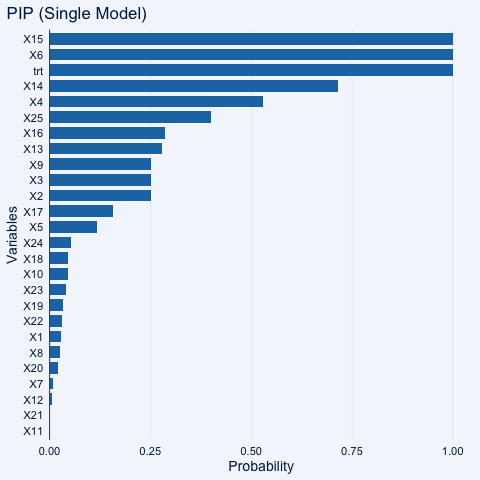

In [ ]:
%%R
plot(fit, method = "pip")

# 플롯을 그릴때 제약을 주고 그릴 수 있다.
# plot(fit, method = "pip", top_n = 10)
# plot(fit, method = "pip", threshold = 0.5)

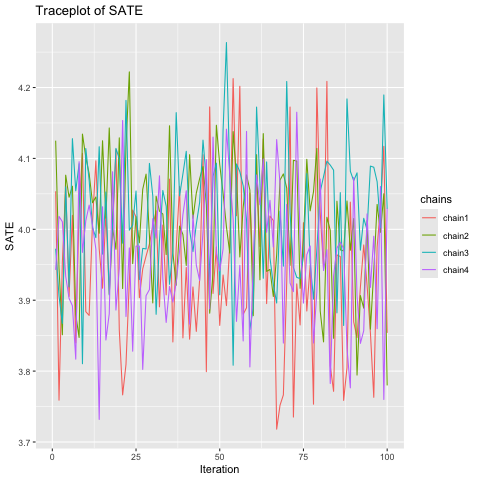

In [ ]:
%%R
plot(fit, method="trace")

# 특정 변수의 트레이스 플롯을 그릴 수 있다.
plot(fit, method="trace", "SATE")
plot(fit, method="trace", "Y1")
plot(fit, method="trace", "dir_alpha")